In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import xgboost

import dagshub
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error

import shap
import lime
from lime import lime_tabular

plt.rcParams["figure.figsize"] = 20, 10
sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)
pd.options.display.max_info_columns = 200
pd.set_option('display.float_format', '{:.4f}'.format)


dagshub.init(repo_owner='kerasPro', repo_name='credit-risk-model', mlflow=True)

Initialized MLflow to track repo "kerasPro/credit-risk-model"

Repository kerasPro/credit-risk-model initialized!

In [20]:
import joblib

best_model = joblib.load("../models/modelo_credito.pkl")

In [21]:
df_test = pd.read_parquet("../data/processed/04_modeling_testing_data.parquet")

In [22]:
X_test = df_test.drop(columns=["loan_status"])
y_test = df_test["loan_status"]

In [23]:
TARGET = "loan_status"

## METODOS GLOBALES

### 1.1 Feature Importance

In [9]:
importance_df =pd.DataFrame(
    {
        "Features": df_test.drop(columns=[TARGET]).columns,
        "Importance": best_model.feature_importances_
    }
).sort_values(by="Importance", ascending=False)

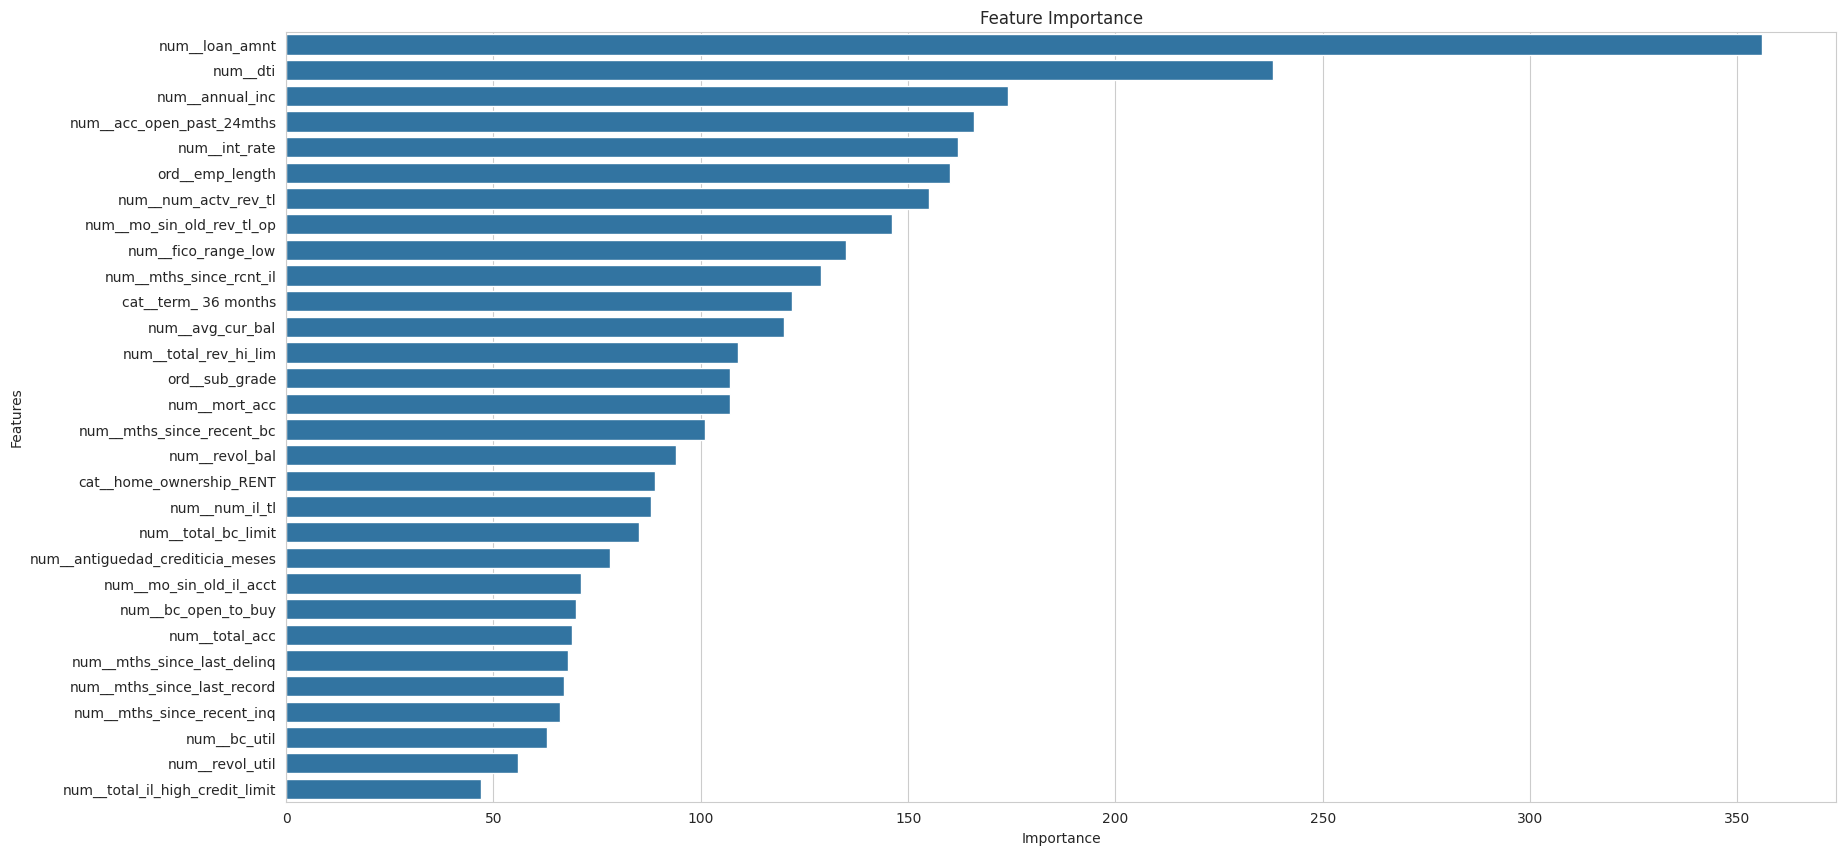

In [32]:
sns.barplot(data=importance_df, x="Importance", y="Features")
plt.title("Feature Importance")
plt.savefig("../reports/figures/feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

Conclusión: Podemos ver que las variables más importantes para el modelo son "num_loan_amnt" y "num_dti"

### 1.2 Permutation Importance

In [33]:
permutation_importances = permutation_importance(
    best_model  , X_test, y_test, n_repeats=5, random_state=42
).importances_mean

permutation_importances_df = pd.DataFrame(
    {
        "Features": X_test.columns,
        "Importance": permutation_importances
    }
).sort_values(by="Importance", ascending=False)

permutation_importances_df

,Features,Importance
0,num__loan_amnt,0.0148
7,cat__term_ 36 months,0.0145
10,num__mths_since_rcnt_il,0.0087
19,num__antiguedad_crediticia_meses,0.0037
5,num__mo_sin_old_rev_tl_op,0.0028
28,cat__home_ownership_RENT,0.0028
11,num__revol_bal,0.0024
4,ord__emp_length,0.0022
15,num__mort_acc,0.0020
12,num__total_bc_limit,0.0016


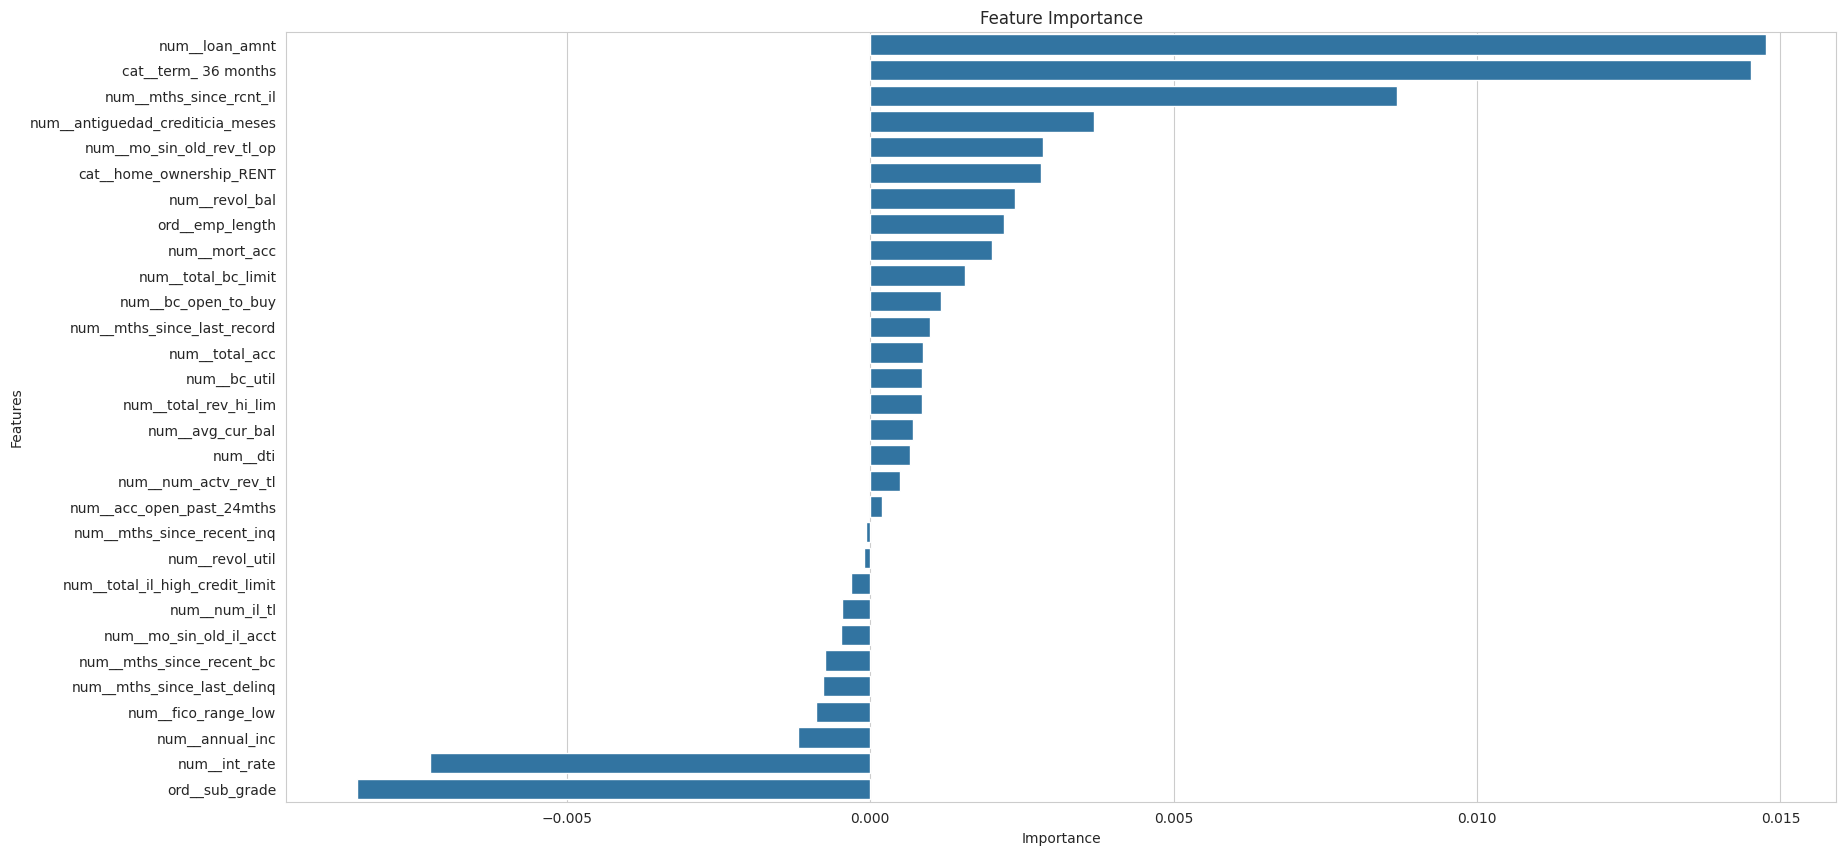

In [35]:
sns.barplot(data=permutation_importances_df, x="Importance", y="Features")
plt.title("Feature Importance")
plt.savefig("../reports/figures/permutation_importance_xgboost.png", dpi=300, bbox_inches='tight')
plt.show()


Conclusión: Podemos observar que num_loan_amnt aporta influye bastante para que un cliente no pague.
y que la variable ord_sub_grade, influye para que un usuario sea considerado como buen pagador.


### SHAP
Global - Feature Importance

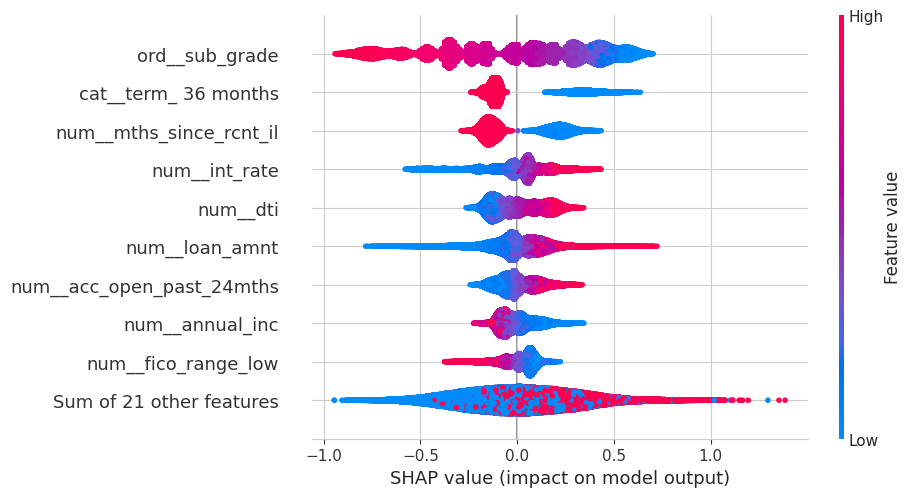

In [36]:
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values, show=False)

# Guardar ANTES de mostrar
plt.savefig("../reports/figures/shap_global_feature_importance_beeswarm_plot.png", dpi=300, bbox_inches='tight')
plt.show()

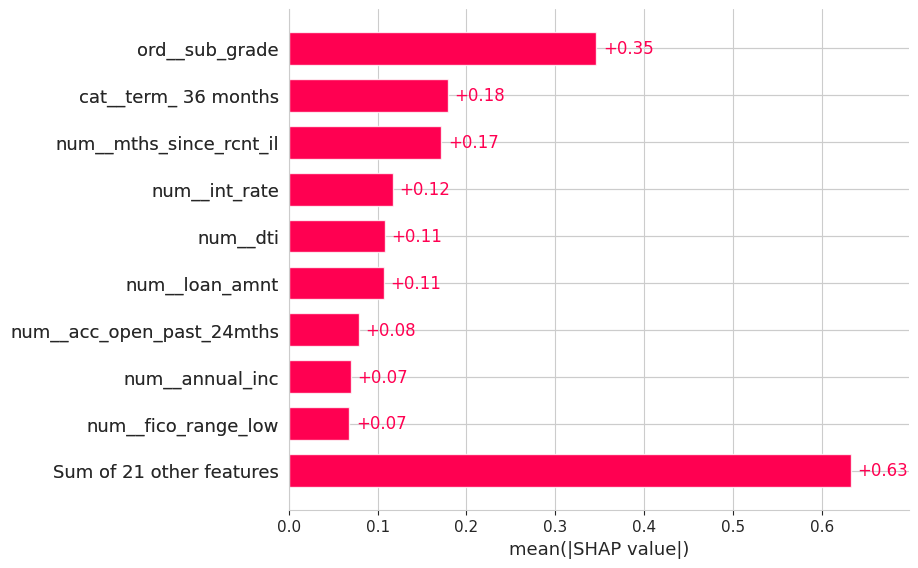

<Figure size 2000x1000 with 0 Axes>

In [37]:
shap.plots.bar(shap_values)
plt.savefig("../reports/figures/bar_plot_shap.png", dpi=300, bbox_inches='tight')
plt.show()

Conclusión: Notablemente, vemos que difiere un poco con feature importance del mismo modelo. Sin embargo, la mayoria de las tendencias se mantiene

## METODOS LOCALES

### Shap

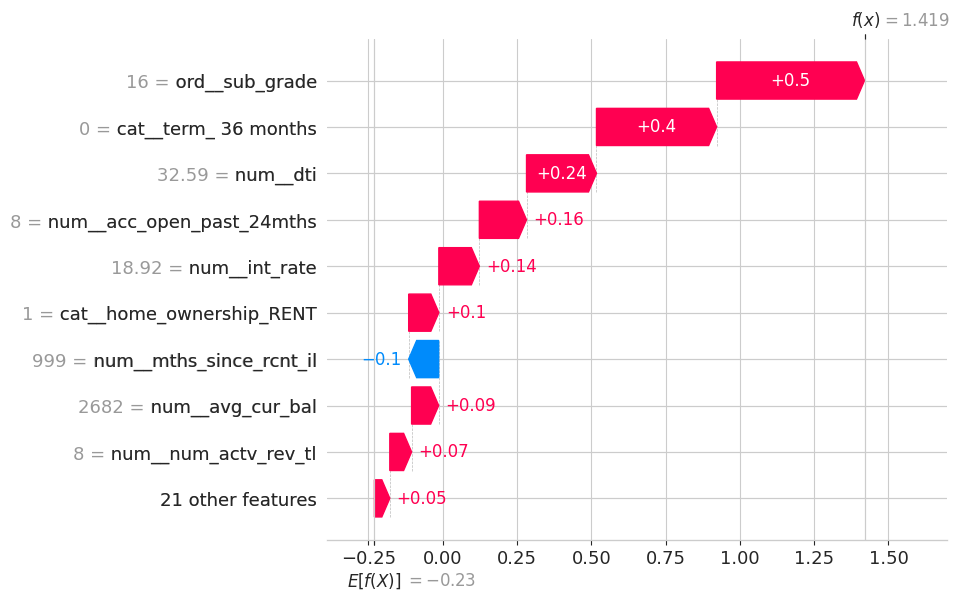

<Figure size 2000x1000 with 0 Axes>

In [38]:
shap.plots.waterfall(shap_values[102])
plt.savefig("../reports/figures/shap_waterfall_plot_user_102.png", dpi=300, bbox_inches='tight')
plt.show()

Para el usuario 102, podemos ver que "num__dti" fue lo que más influyó para que sea un cliente aceptado.

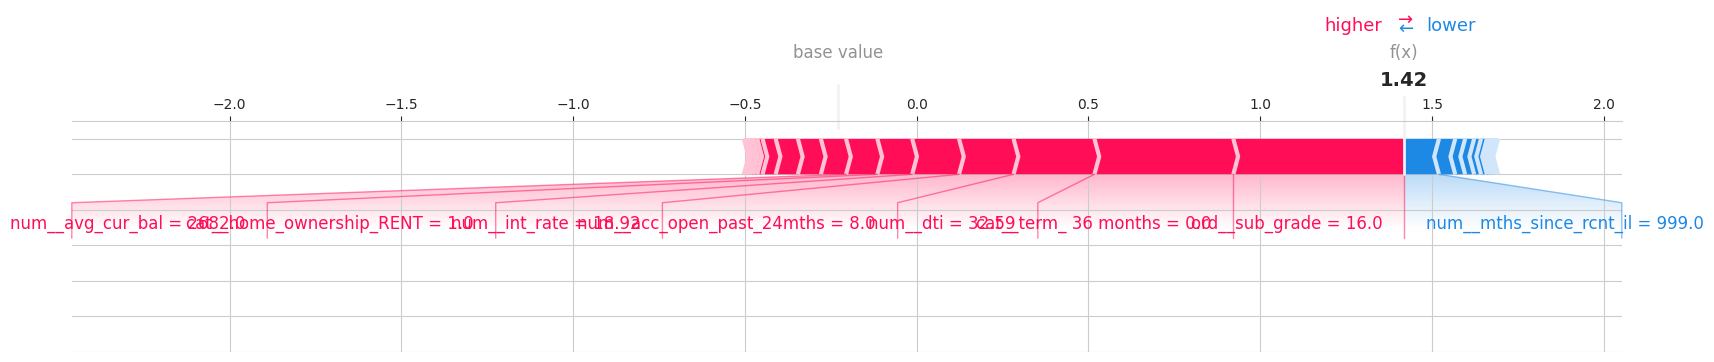

<Figure size 2000x1000 with 0 Axes>

In [39]:
shap.plots.force(shap_values[102],matplotlib=True)
plt.savefig("../reports/figures/shap_force_plot_user_102.png", dpi=300, bbox_inches='tight')
plt.show()